In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. Veriyi Yükle
df = pd.read_csv('../data/processed/temiz_veri.csv')

# 2. Verinin boş olup olmadığını kontrol et
if df.empty:
    print("❌ HATA: DataFrame boş! 'temiz_veri.csv' dosyasını kontrol etmelisin.")
else:
    print(f"✅ Veri yüklendi. Boyut: {df.shape[0]} satır, {df.shape[1]} sütun.")

    # 3. Özet tabloyu manuel hesaplayarak oluştur
    # (Eğer hata veriyorsa Series bazlı oluşturup concat edeceğiz)
    
    types = df.dtypes
    counts = df.count()
    nulls = df.isnull().sum()
    percents = (nulls / len(df) * 100).round(2)

    # Dictionary yerine concat kullanarak daha sağlam bir yapı kuralım
    ozet_df = pd.concat([types, counts, nulls, percents], axis=1)
    ozet_df.columns = ['Veri Tipi', 'Dolu Gözlem', 'Eksik (NaN)', 'Eksik %']

    # 4. Çıktı ayarlarını yap ve GÖRÜNTÜLE
    pd.set_option('display.max_rows', None) # Tüm satırları göster
    
    print("\n--- 20 SÜTUNLUK ANALİZ TABLOSU ---")
    print(ozet_df) # 'display' yerine 'print' daha garantidir

print("\n--- 2. İSTATİSTİKSEL ÖZET (20 SÜTUN) ---")
# describe().T kullanarak tüm sütunları satır bazında listeliyoruz (daha okunaklı)
display(df.describe(include='all').T)

print("\n--- 3. EKSİK VERİ ANALİZİ (TAM LİSTE) ---")
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Eksik Sayısı': missing_count,
    'Yüzde (%)': missing_percent
}).sort_values(by='Eksik Sayısı', ascending=False)
display(missing_df)

# --- 4. GÖRSELLEŞTİRME ---


✅ Veri yüklendi. Boyut: 22656 satır, 20 sütun.

--- 20 SÜTUNLUK ANALİZ TABLOSU ---
         Veri Tipi  Dolu Gözlem  Eksik (NaN)  Eksik %
year       float64        22656            0     0.00
realinc    float64        20175         2481    10.95
income     float64        18563         4093    18.07
educ       float64        21783          873     3.85
health     float64        18606         4050    17.88
happy      float64        22551          105     0.46
class      float64        22476          180     0.79
prestg10   float64        21532         1124     4.96
paeduc     float64        14806         7850    34.65
age        float64        21980          676     2.98
sex          int64        22656            0     0.00
race       float64        22484          172     0.76
marital    float64        22609           47     0.21
polviews   float64        21849          807     3.56
trust      float64        10032        12624    55.72
satfin     float64        22564           92     0.41

,count,mean,std,min,25%,50%,75%,max
year,22656.0,2018.090219,4.534804,2010.0,2014.0,2018.0,2022.0,2024.0000
realinc,20175.0,34476.565587,34366.367678,181.5,11247.5,24502.5,43560.0,155139.9731
income,18563.0,11.218715,2.315257,1.0,12.0,12.0,12.0,12.0000
educ,21783.0,14.202773,2.804362,1.0,12.0,14.0,16.0,20.0000
health,18606.0,2.110072,0.794991,1.0,2.0,2.0,3.0,4.0000
happy,22551.0,1.932597,0.656455,1.0,1.0,2.0,2.0,3.0000
class,22476.0,2.414487,0.715276,1.0,2.0,2.0,3.0,4.0000
prestg10,21532.0,44.668354,13.623617,16.0,35.0,45.0,53.0,80.0000
paeduc,14806.0,12.758544,3.640941,1.0,12.0,12.0,16.0,20.0000
age,21980.0,49.609736,17.733143,18.0,35.0,49.0,64.0,89.0000



--- 3. EKSİK VERİ ANALİZİ (TAM LİSTE) ---


,Eksik Sayısı,Yüzde (%)
trust,12624,55.720339
natfare,11652,51.430085
paeduc,7850,34.648658
childs,6877,30.353990
income,4093,18.065855
health,4050,17.876059
realinc,2481,10.950742
prestg10,1124,4.961158
educ,873,3.853284
polviews,807,3.561970


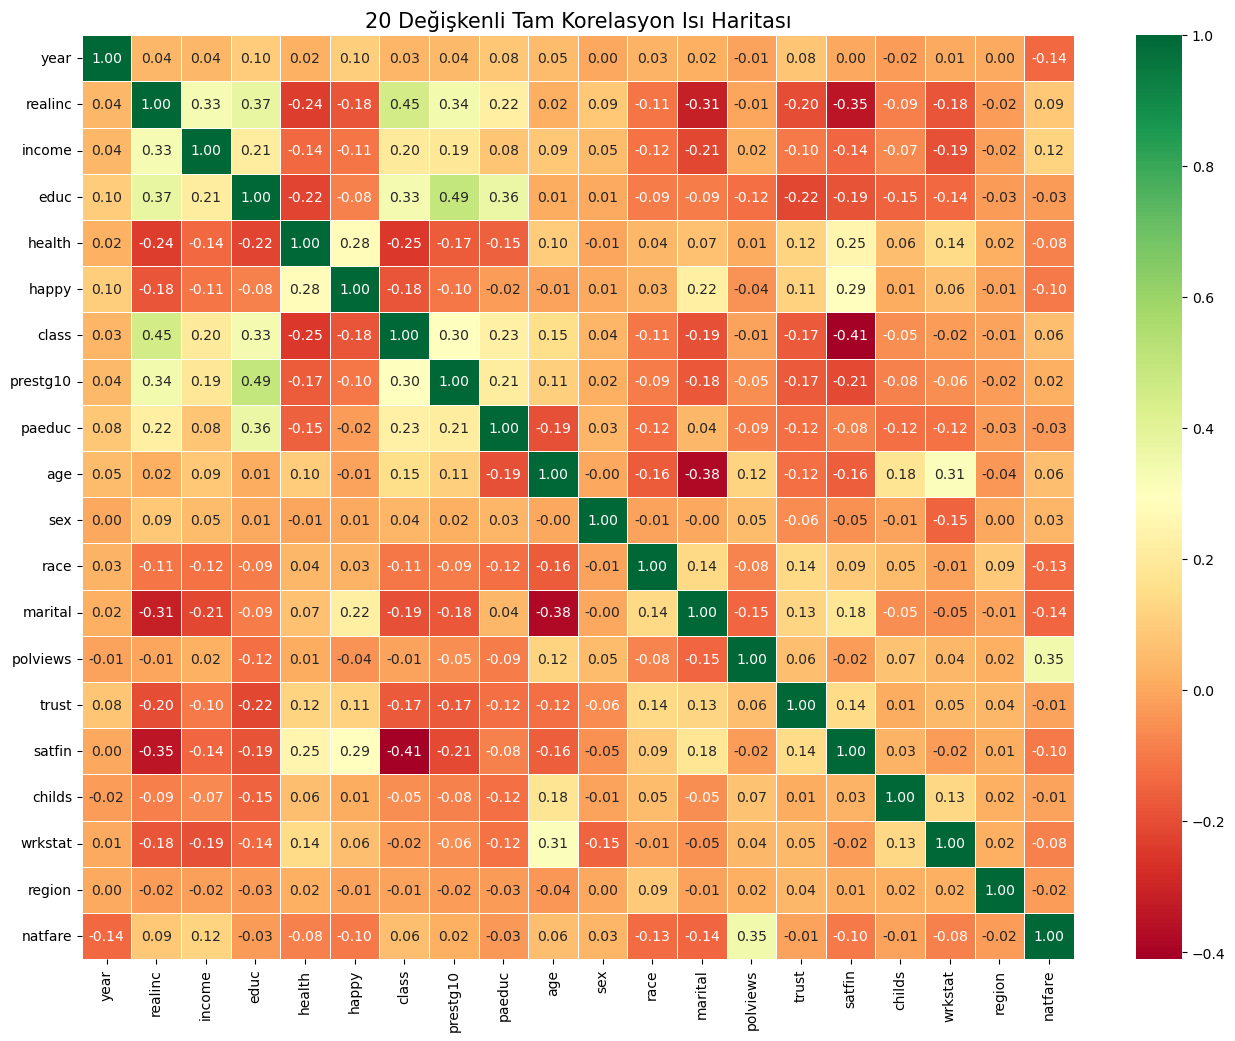

In [3]:
# A. Korelasyon Matrisi (20x20 Tam Matris)
plt.figure(figsize=(16, 12))
# Sadece sayısal sütunlar için korelasyon hesapla
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('20 Değişkenli Tam Korelasyon Isı Haritası', fontsize=15)
plt.show()

Isı haritasına (image_f27975.png) baktığımızda, mutluluk üzerinde en belirgin etkinin finansal tatmin ve sağlık durumundan geldiğini görüyoruz. Eğitim seviyesi yükseldikçe mesleki saygınlık ve gelir de paralel olarak artış gösteriyor. Ayrıca bireylerin reel gelirleri ile kendilerini ait hissettikleri sosyal sınıf arasında güçlü bir bağ mevcut.

Yaş ilerledikçe medeni durumun değişmesi beklenen bir demografik hareket olarak verilere yansımış durumda. Teknik bir detay olarak, GSS puanlama sisteminde düşük sayıların (örneğin 1) en iyi durumu temsil etmesi nedeniyle bazı değişkenler arasında "ters" gibi görünen ama aslında pozitif olan korelasyonlar bulunduğunu unutmamak gerekiyor.

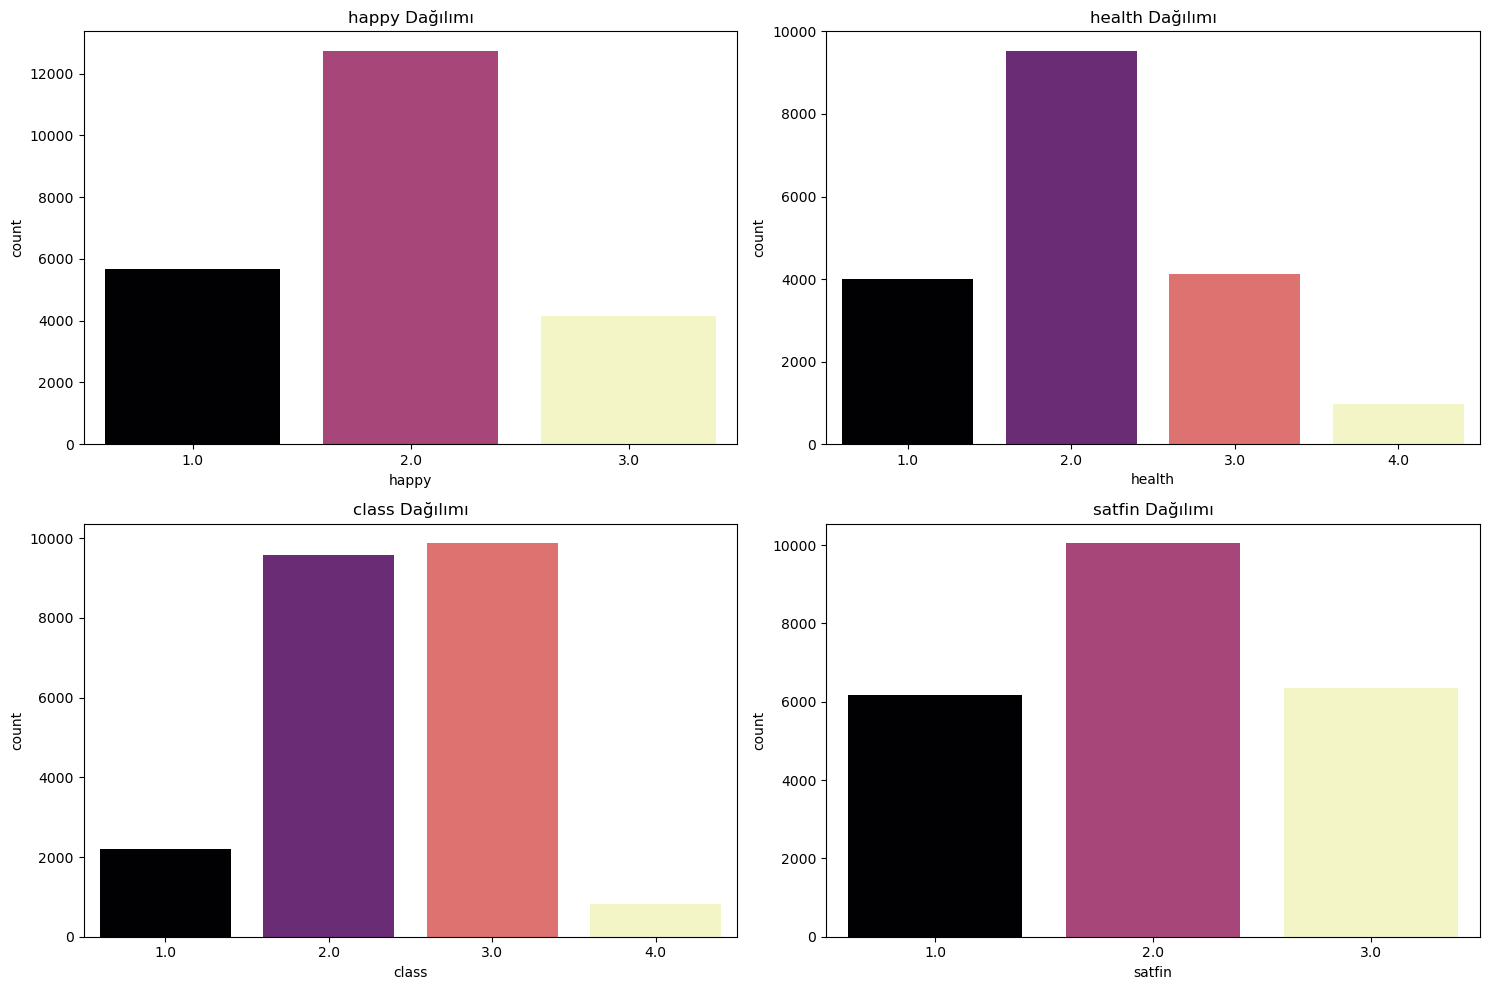

In [4]:
# B. Hedef Değişken ve Kritik Sütunların Dağılımı (Subplots)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
cols_to_plot = ['happy', 'health', 'class', 'satfin']

# Hatanın çözümü: Döngüyü ekledik
for i, col in enumerate(cols_to_plot):
    sns.countplot(x=col, data=df, ax=axes[i//2, i%2], hue=col, palette='magma', legend=False)
    axes[i//2, i%2].set_title(f'{col} Dağılımı')

plt.tight_layout()
plt.show()

happy (Mutluluk): Katılımcıların çoğu "2.0" (Mutlu) grubunda. "1.0" (Çok Mutlu) sayısı, mutsuz olanlara göre daha fazla; yani genel hava pozitif.

health (Sağlık): "2.0" seviyesi baskın, örneklem genelde sağlıklı. "4.0" (Kötü) oranının çok düşük olması, fiziksel refahın yüksek bir tabana yayıldığını gösteriyor.

class (Sosyal Sınıf): "2.0" (İşçi Sınıfı) ve "3.0" (Orta Sınıf) arasında dengeli bir dağılım var. Veri seti toplumun ana gövdesini iyi temsil ediyor.

satfin (Finansal Tatmin): "2.0" (Kısmen Memnun) seviyesi merkezde. Tam memnun olanlar ile hiç memnun olmayanların sayıca birbirine yakın olması simetrik bir yapı sunuyor.

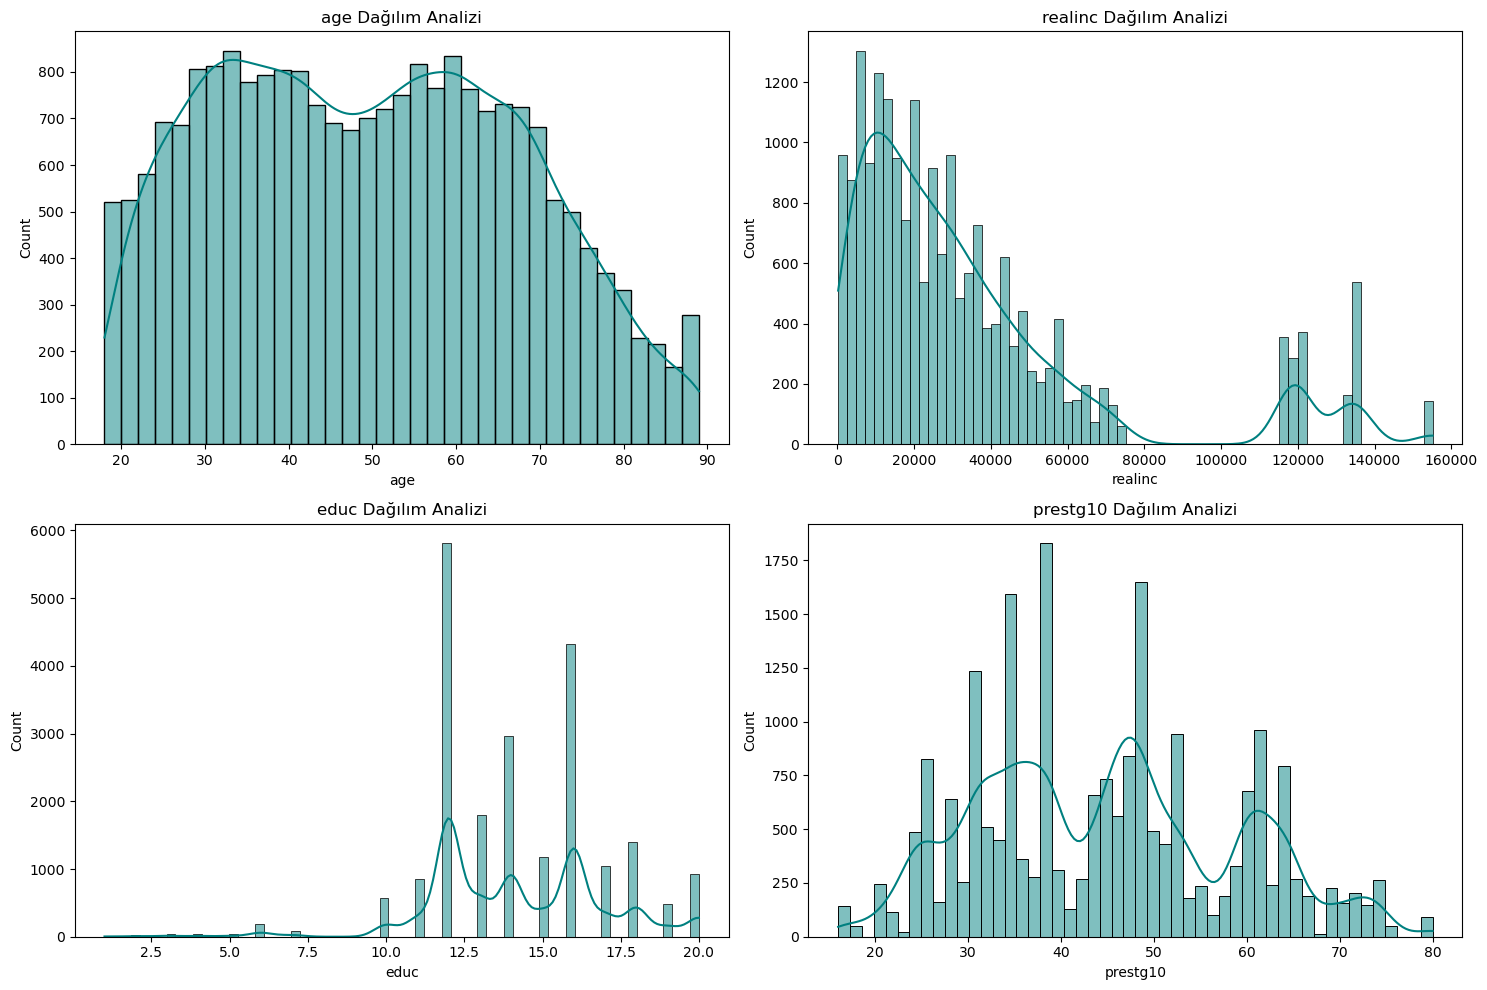

In [5]:
# 1. Tek Değişkenli Analiz (Univariate) - Sayısal Değişkenlerin Dağılımı
# Önemli sayısal sütunları seçelim
num_cols = ['age', 'realinc', 'educ', 'prestg10']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'{col} Dağılım Analizi')
plt.tight_layout()
plt.show()

age (Yaş): Örneklem 20 ile 90 yaş arasına geniş bir şekilde yayılmış durumda. 30-40 ve 60 yaş civarlarında iki ana yoğunluk (bimodal eğilim) göze çarpıyor; bu da hem genç hem de emeklilik yaşına yakın kitlenin veri setinde güçlü temsil edildiğini gösteriyor.

realinc (Reel Gelir): Sağa çarpık (right-skewed) bir dağılım söz konusu. Çoğunluk düşük ve orta gelir grubunda toplanırken, 120.000$ ve üzeri seviyelerde uç değerler (outliers) mevcut. Bu, ekonomik eşitsizliği yansıtan tipik bir gelir dağılımıdır.

educ (Eğitim Süresi): Kesikli ve belirli yıllarda (12. yıl - lise, 16. yıl - lisans) çok yüksek sivrilmeler (spikes) görülüyor. Bu, eğitim seviyelerinin mezuniyet yıllarına göre kümelendiğini kanıtlıyor.

prestg10 (Mesleki Saygınlık): Çok modlu (multimodal) bir dağılım sergiliyor. 30-40 ve 50-60 puan aralıklarındaki dalgalanmalar, veri setindeki meslek gruplarının saygınlık algısı bakımından farklı toplumsal katmanlara ayrıldığını işaret ediyor.

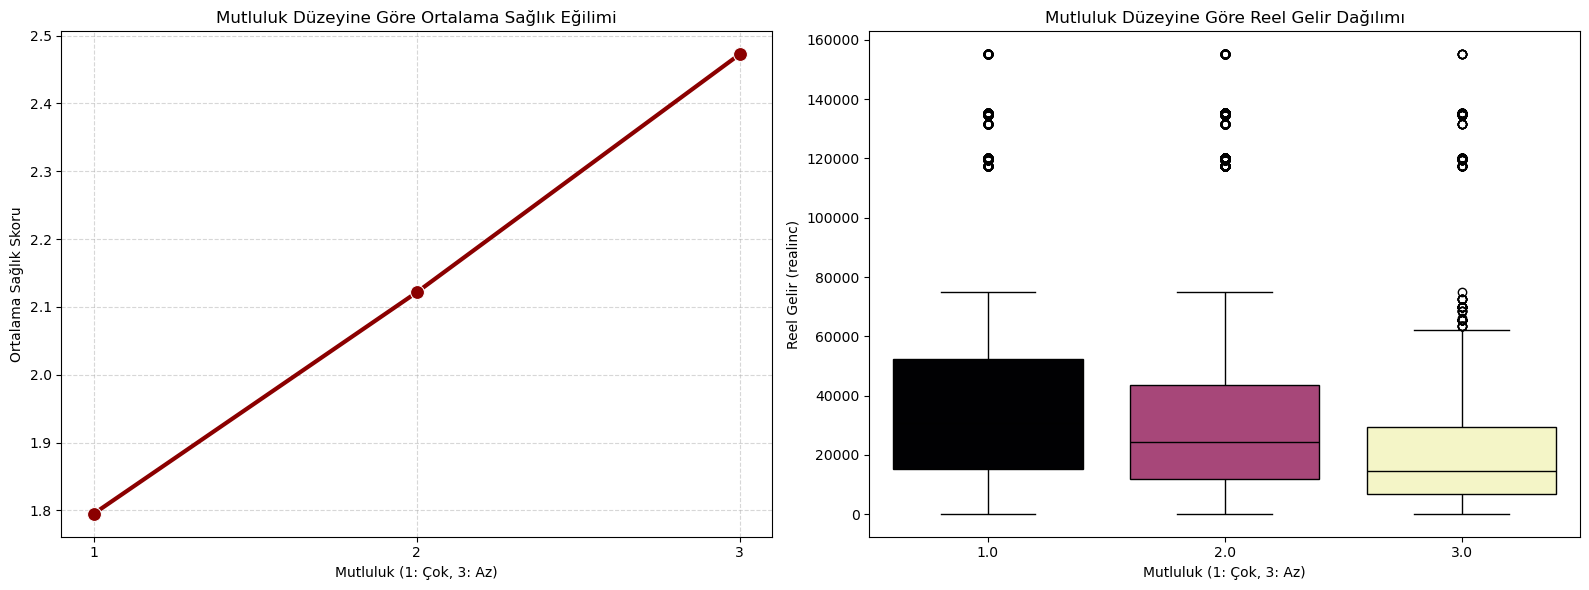

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi hazırlama: Mutluluk düzeyine göre sağlık ortalamalarını alıyoruz
health_trend = df.groupby('happy')['health'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Grafik: Sağlık ve Mutluluk Eğilimi (Line Plot)
sns.lineplot(x='happy', y='health', data=health_trend, marker='o', 
             ax=axes[0], color='darkred', linewidth=3, markersize=10)
axes[0].set_title('Mutluluk Düzeyine Göre Ortalama Sağlık Eğilimi')
axes[0].set_xlabel('Mutluluk (1: Çok, 3: Az)')
axes[0].set_ylabel('Ortalama Sağlık Skoru')
axes[0].set_xticks([1, 2, 3])
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Grafik: Gelir ve Mutluluk Dağılımı (Box Plot)
sns.boxplot(x='happy', y='realinc', data=df, ax=axes[1], 
            palette='magma', hue='happy', legend=False)
axes[1].set_title('Mutluluk Düzeyine Göre Reel Gelir Dağılımı')
axes[1].set_xlabel('Mutluluk (1: Çok, 3: Az)')
axes[1].set_ylabel('Reel Gelir (realinc)')

plt.tight_layout()
plt.show()

1. Ortalama Sağlık Eğilimi (Sol Grafik)
-Mutluluk ve sağlık arasında doğrusal ve güçlü bir bağ görülüyor.
-Mutluluk seviyesi azaldıkça (1'den 3'e gittikçe), sağlık skoru da yükseliyor.
-Veri setindeki kodlamaya göre yüksek skor "daha kötü sağlık" demek olduğundan; en mutlu grubun sağlık algısı en iyiyken, en mutsuz grubun sağlık algısı belirgin şekilde daha kötüdür.

2. Reel Gelir Dağılımı (Sağ Grafik)
-Gelir yükseldikçe mutluluk olasılığının arttığı box plot üzerinden okunabiliyor.
-"Çok Mutlu" (1.0) olan grubun hem medyan geliri hem de gelir tavanı, diğer iki gruba göre çok daha yukarıdadır.
-Mutluluk azaldıkça kutuların aşağı kayması, düşük gelirin mutsuzluk üzerinde baskılayıcı bir faktör olduğunu kanıtlıyor.
-Her üç grupta da görülen uç değerler (üstteki noktalar), çok yüksek gelirin her zaman "çok mutlu" olma garantisi vermediğini ancak genel eğilimi bozmadığını gösteriyor.